# Weak-lensing galaxy shape catalogue validation 1

## PSF leakage

Contents
- Linear fit PSF leakage
- Scale-dependent PSF leakage alpha
- Cross-correlation function xi_sys

> **_NOTE:_** Before running this notebook, set kernel to `main_set.ipynb'

In [49]:
%matplotlib inline

import os
from uncertainties import ufloat

In [50]:
from sp_validation.survey import *
from sp_validation.util import *
from sp_validation.basic import *
from sp_validation.plots import *
from sp_validation.galaxy import *
from sp_validation.cat import *
from sp_validation.correlation import *
from sp_validation.cosmology import *

Could not import clmm, continuing...
Could not import clmm.Cosmology, continuing...


### Linear fit
Fit galaxy ellipticity as function of (binned) PSF ellipticity.

In [51]:
n_bin = 30

colors = ['b', 'r']
ylabel = r'$e_{1,2}^{\rm gal}$'
mlabel = ['m_1', 'm_2']

xlabel_arr = [
    r'$e_{1}^{\rm PSF}$',
    r'$e_{2}^{\rm PSF}$',
    r'$\mathrm{FWHM}^{\rm PSF}$ [arcsec]'
]

In [52]:
sp_base = f"{os.environ['HOME']}/sp_validation"

for sc in ['correlation']:
    script = os.path.join(sp_base, 'sp_validation', sc)
    %run $script

<Figure size 432x288 with 0 Axes>

ngmix:


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:01<00:00, 15.95it/s]


$e_{1}^{\rm PSF}$: m_1=0.012±0.013
$e_{1}^{\rm PSF}$: m_2=0.003±0.013


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:01<00:00, 16.07it/s]


$e_{2}^{\rm PSF}$: m_1=0.046±0.012
$e_{2}^{\rm PSF}$: m_2=0.005±0.012


...

$e_{1}^{\rm PSF}$: m_1=0.01±inf
$e_{1}^{\rm PSF}$: m_2=0.01±inf


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:00<00:00, 55.24it/s]
/home/mkilbing/sp_validation/sp_validation/correlation.py:131: RuntimeWarning: invalid value encountered in sqrt
  res = curve_fit(lin, x, y[j], p0=[0.01, 0.01], sigma=1/np.sqrt(weights))
/home/mkilbing/sp_validation/sp_validation/correlation.py:131: RuntimeWarning: divide by zero encountered in true_divide
  res = curve_fit(lin, x, y[j], p0=[0.01, 0.01], sigma=1/np.sqrt(weights))
/home/mkilbing/.conda/envs/sp_validation/lib/python3.8/site-packages/scipy/optimize/minpack.py:828: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/home/mkilbing/sp_validation/sp_validation/correlation.py:131: RuntimeWarning: invalid value encountered in sqrt
  res = curve_fit(lin, x, y[j], p0=[0.01, 0.01], sigma=1/np.sqrt(weights))
/home/mkilbing/sp_

$e_{2}^{\rm PSF}$: m_1=0.01±inf
$e_{2}^{\rm PSF}$: m_2=0.01±inf


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [00:00<00:00, 55.03it/s]
/home/mkilbing/sp_validation/sp_validation/correlation.py:131: RuntimeWarning: invalid value encountered in sqrt
  res = curve_fit(lin, x, y[j], p0=[0.01, 0.01], sigma=1/np.sqrt(weights))
/home/mkilbing/sp_validation/sp_validation/correlation.py:131: RuntimeWarning: divide by zero encountered in true_divide
  res = curve_fit(lin, x, y[j], p0=[0.01, 0.01], sigma=1/np.sqrt(weights))
/home/mkilbing/.conda/envs/sp_validation/lib/python3.8/site-packages/scipy/optimize/minpack.py:828: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',
/home/mkilbing/sp_validation/sp_validation/correlation.py:131: RuntimeWarning: invalid value encountered in sqrt
  res = curve_fit(lin, x, y[j], p0=[0.01, 0.01], sigma=1/np.sqrt(weights))
/home/mkilbing/sp_

$\mathrm{FWHM}^{\rm PSF}$ [arcsec]: m_1=0.01±inf
$\mathrm{FWHM}^{\rm PSF}$ [arcsec]: m_2=0.01±inf


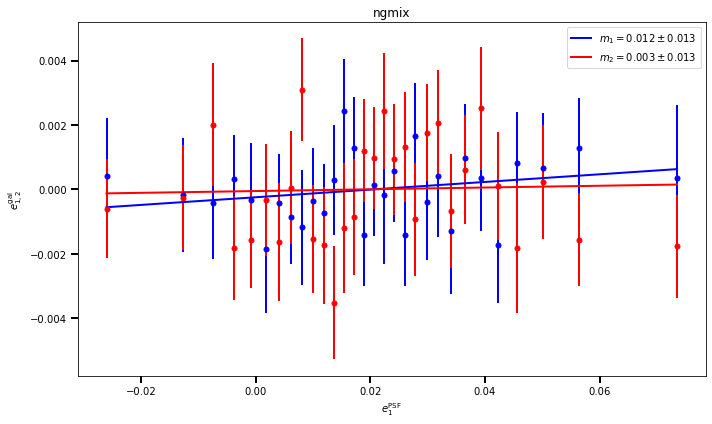

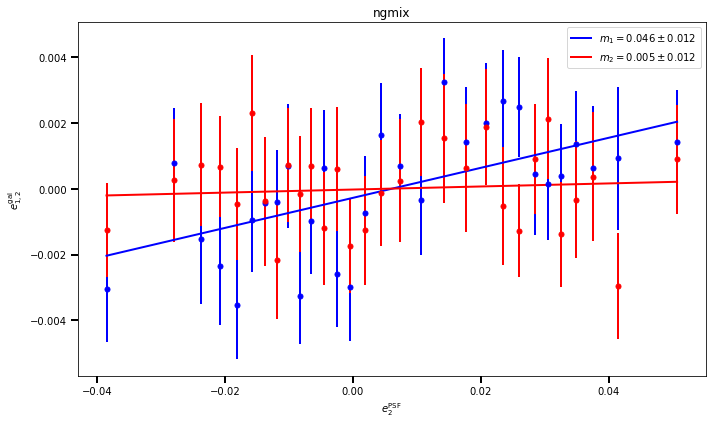

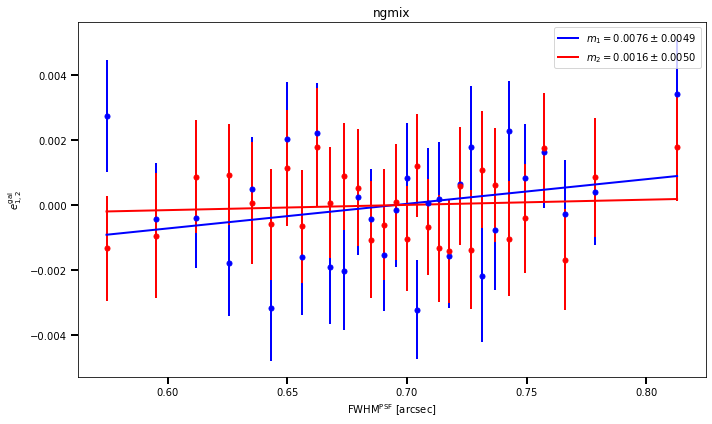

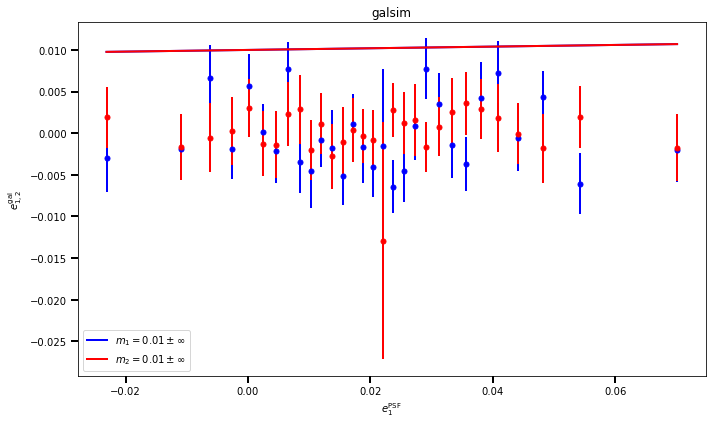

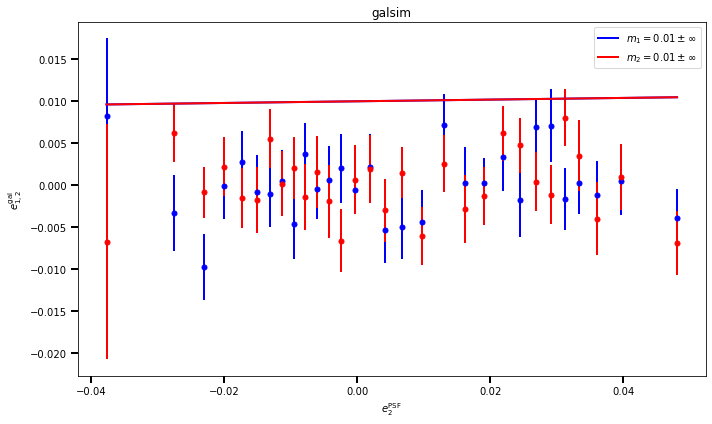

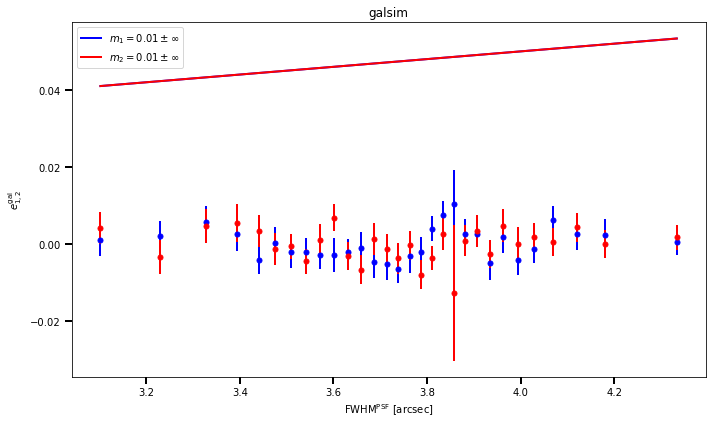

In [53]:
for sh in shapes:
    plot_dir_leakage = f'{plot_dir}/psf_leak_{sh}'
    print_stats(f'{sh}:', stats_file, verbose=verbose)
    
    e1 = g_corr[sh][0] - c[sh][0]
    e2 = g_corr[sh][1] - c[sh][1]
    e = [e1, e2]
    weights = w[sh]

    x_arr = [
        dd[key_PSF_ell[sh]][:,0][m_gal[sh]][mask[sh]],
        dd[key_PSF_ell[sh]][:,1][m_gal[sh]][mask[sh]],
        size_to_fwhm[sh](dd[key_PSF_size[sh]][m_gal[sh]][mask[sh]])
    ]
    out_name_arr = [
        'PSF_e1_vs_e_gal',
        'PSF_e2_vs_e_gal',
        'PSF_size_vs_e_gal'
    ]
    out_path_arr = [f'{plot_dir_leakage}/{name}' for name in out_name_arr]
    affine_corr_n(
        x_arr,
        e,
        xlabel_arr,
        ylabel,
        mlabel=mlabel,
        title=sh,
        weights=weights,
        n_bin=n_bin,
        out_path_arr=out_path_arr,
        colors=colors,
        stats_file=stats_file,
        verbose=True
    )

### Scale-dependent leakage
Compute scale-dependent leakage $\alpha(\theta)$ from cross-correlations betwen galaxy and PSF ellipticities,
$$
    \alpha(\theta) = \frac{\xi_{+}^{\rm gp}(\theta) - \langle e_{\rm gal} \rangle^{*} \langle e_{\rm PSF} \rangle}{\xi_{+}^{\rm pp}(\theta) - |\langle e_{\rm PSF} \rangle|^{2}}
$$
With g = galaxy and p = PSF.

In [54]:
r_corr_gp = {}
r_corr_pp = {}
alpha_leak = {}
sig_alpha_leak = {}

for sh in shapes:

    e1_gal = g_corr[sh][0] - c[sh][0]
    e2_gal = g_corr[sh][1] - c[sh][1]
    weights = w[sh]
    e1_star = g_star_psf[sh][0]
    e2_star = g_star_psf[sh][1]

    # Correlation functions
    r_corr_gp[sh], r_corr_pp[sh] = correlation_12_22(
        ra[sh],
        dec[sh],
        e1_gal,
        e2_gal, 
        weights,
        ra_star[sh],
        dec_star[sh],
        e1_star,
        e2_star
    )

    # Leakage
    alpha_leak[sh], sig_alpha_leak[sh] = alpha(
        r_corr_gp[sh],
        r_corr_pp[sh],
        e1_gal,
        e2_gal,
        weights,
        e1_star,
        e2_star
    )

In [55]:
alpha_leak_mean = {}

for sh in shapes:
    alpha_leak_mean[sh] = transform_nan(
        np.average(alpha_leak[sh],
                   weights=1/sig_alpha_leak[sh]**2)
    )
    print_stats(
        f'{sh}: Weighted average alpha = {alpha_leak_mean[sh]:.3g}',
        stats_file,
        verbose=verbose
    )

ngmix: Weighted average alpha = 0.0406
galsim: Weighted average alpha = 0.0575


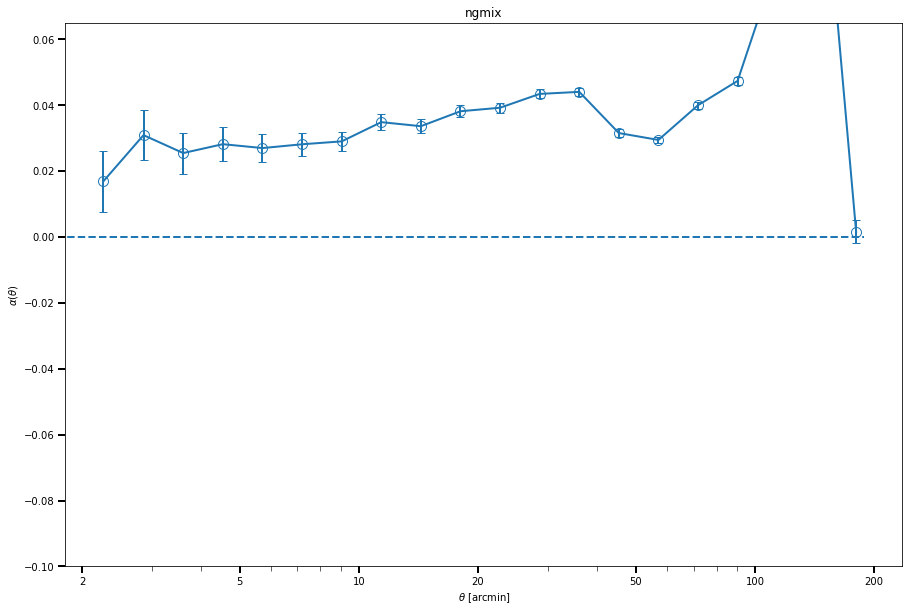

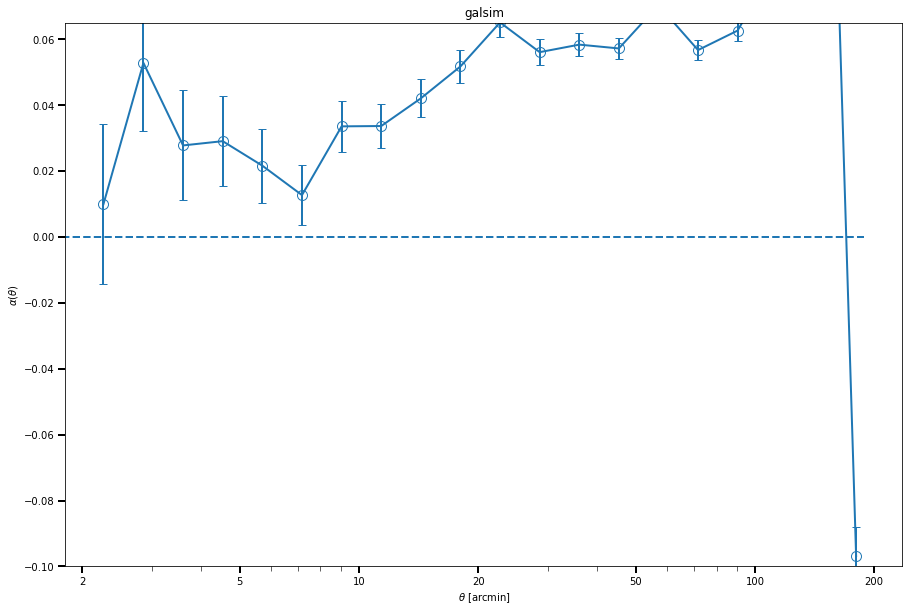

In [56]:
for sh in shapes:
    plot_dir_leakage = f'{plot_dir}/psf_leak_{sh}'

    theta = [r_corr_gp[sh].meanr]
    alpha_theta = [alpha_leak[sh]]
    yerr = [sig_alpha_leak[sh]]
    xlabel = r'$\theta$ [arcmin]'
    ylabel = r'$\alpha(\theta)$'
    title = sh
    out_path = f'{plot_dir_leakage}/alpha_leakage{sh}.png'
    try:
        ylim  = leakage_alpha_ylim
    except:
        ylim = None

    plot_data_1d(theta, alpha_theta, yerr, title, xlabel, ylabel, out_path, xlog=True, ylim=ylim)

### Cross-correlation PSF leakage
Compute $\xi^{\rm sys}$, the normalised cross-correlation function of galaxy and star ellipticities:
$$
\xi^{\rm sys}(\theta) = \frac{\left( \xi_{\pm}^{\rm gp}(\theta) \right)^2}{\xi_{\pm}^{\rm pp}(\theta)}
$$   
With $g$: galaxy and $p$: PSF.

In [57]:
C_sys_p = {}
C_sys_m = {}
C_sys_std_p = {}
C_sys_std_m = {}

for sh in shapes:
    C_sys_p[sh] = r_corr_gp[sh].xip**2 / r_corr_pp[sh].xip
    C_sys_m[sh] = r_corr_gp[sh].xim**2 / r_corr_pp[sh].xim

    C_sys_std_p[sh] = (
        np.abs(C_sys_p[sh])
        * np.sqrt(
            (((2*r_corr_gp[sh].xip**2 * np.sqrt(r_corr_gp[sh].varxip)) \
              / r_corr_gp[sh].xip)/r_corr_gp[sh].xip**2)**2
            + (np.sqrt(r_corr_pp[sh].varxip)/r_corr_pp[sh].xip)**2
        )
    )
    
    C_sys_std_m[sh] = (
        np.abs(C_sys_m[sh])
        * np.sqrt(
            (((2*r_corr_gp[sh].xim**2 * np.sqrt(r_corr_gp[sh].varxim)) \
              / r_corr_gp[sh].xim)/r_corr_gp[sh].xim**2)**2
            + (np.sqrt(r_corr_pp[sh].varxim)/r_corr_pp[sh].xim)**2
        )
    )

#### Theoretical prediction

In [58]:
# Redshift distribution

nz_base = 'nz.CFHTLenSmatched.W3'
nz_ext = 'txt'
nz_date = '202012'
nz_version = 'v1'
nz_name = '{}_{}_{}.{}'.format(nz_base, nz_date, nz_version, nz_ext)
source = f'vos:cfis/cosmostat/cosmology/redshifts/{nz_name}'
target = f'{data_dir}/{nz_name}'

download(source, target, verbose=True)

z, nz = np.loadtxt(target, unpack=True)

Target file /home/mkilbing/data_WL/nz.CFHTLenSmatched.W3_202012_v1.txt exists, skipping download.


In [59]:
for sh in shapes:
    try:
        xi_p_planck, xi_m_planck = get_theo_xi(
            r_corr_gp[sh].meanr, 
            z,
            nz,
            Omega_m=Om,
            h=h,
            Omega_b=Ob, 
            sig8=sig8,
            ns=ns
        )
    except:
        print('Computation of theoretical prediction failed')

/home/mkilbing/.conda/envs/sp_validation/lib/python3.8/site-packages/pyccl/correlations.py:83: CCLWarning: corr_type is deprecated. Use type = GG+
  warnings.warn("corr_type is deprecated. Use type = {}".format(type),
/home/mkilbing/.conda/envs/sp_validation/lib/python3.8/site-packages/pyccl/correlations.py:83: CCLWarning: corr_type is deprecated. Use type = GG-
  warnings.warn("corr_type is deprecated. Use type = {}".format(type),


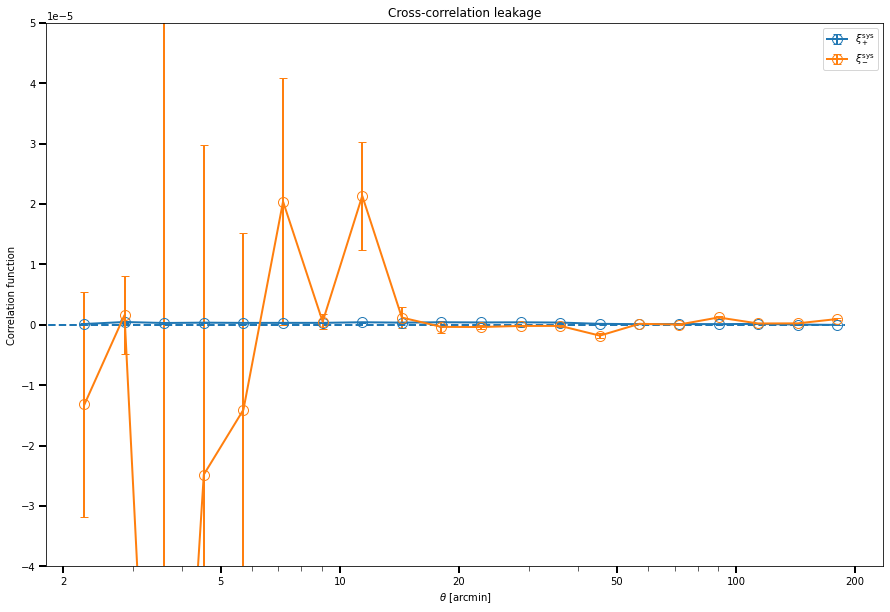

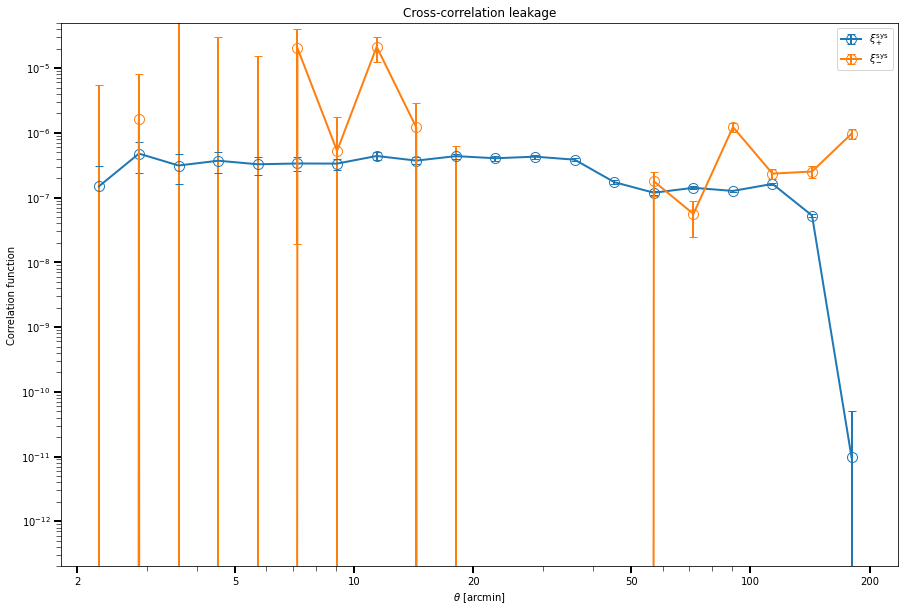

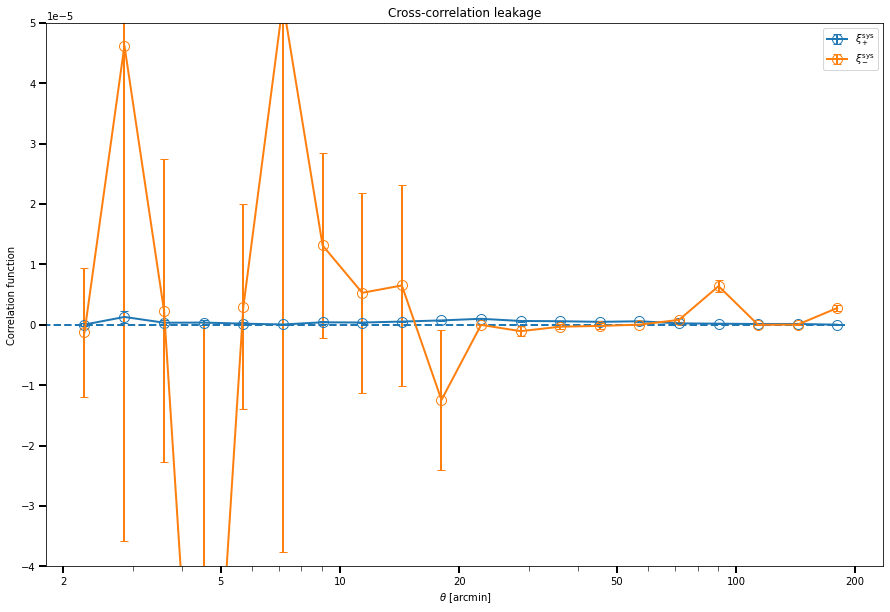

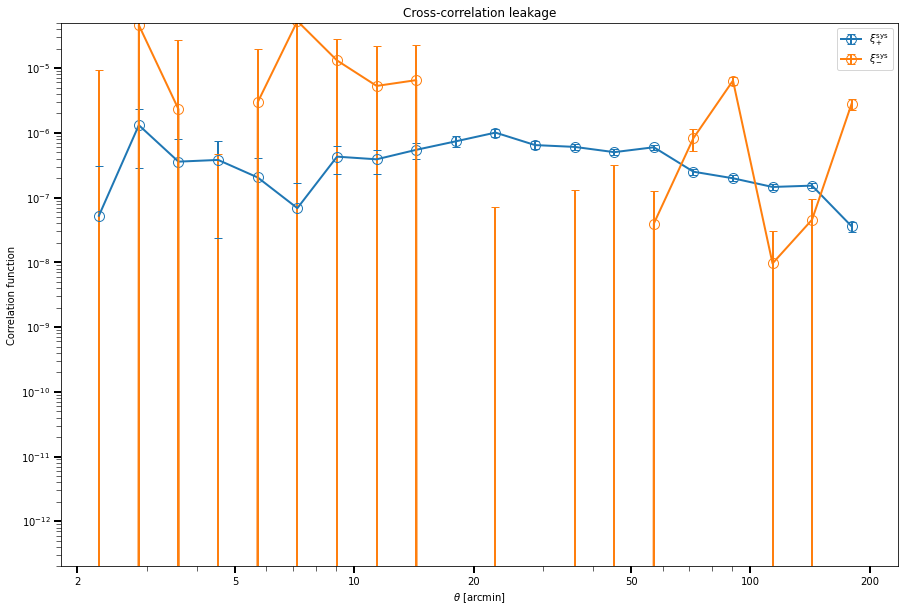

In [60]:
labels = ['$\\xi^{\\rm sys}_+$', '$\\xi^{\\rm sys}_-$']

title = 'Cross-correlation leakage'
xlabel = '$\\theta$ [arcmin]'
ylabel = 'Correlation function'

for sh in shapes:
    plot_dir_leakage = f'{plot_dir}/psf_leak_{sh}'

    theta = [r_corr_gp[sh].meanr] * 2
    xi = [C_sys_p[sh], C_sys_m[sh]]
    yerr = [C_sys_std_p[sh], C_sys_std_m[sh]]

    try:
        ylim = leakage_xi_sys_ylim
    except:
        ylim = None
    out_path = f'{plot_dir}/xi_sys_{sh}.pdf'
    
    plot_data_1d(
        theta,
        xi,
        yerr,
        title,
        xlabel,
        ylabel,
        out_path,
        xlog=True,
        ylim=ylim,
        labels=labels
    )

    try:
        ylim = leakage_xi_sys_log_ylim
    except:
        ylim = None
    out_path = f'{plot_dir}/xi_sys_log[sh].pdf'
    plot_data_1d(
        theta,
        xi,
        yerr,
        title,
        xlabel,
        ylabel,
        out_path,
        xlog=True, 
        ylog=True,
        ylim=ylim,
        labels=labels
    )